In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_image(image_path, target_size=None):
    """
    加载图像，转换为灰度图，并归一化到[0, 1]范围。
    可以选择将图像调整到目标尺寸。
    """
    # 以灰度模式读取图像
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"错误：无法加载图像 {image_path}")

    # 如果指定了目标尺寸，则调整图像大小
    if target_size is not None:
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

    # 将图像数据类型转换为浮点型并归一化到 [0, 1]
    img_float = img.astype(np.float32) / 255.0
    return img_float

def reconstruct_object(O_ref, S_ref, S_unknown, epsilon=1e-8):
    """
    使用参考物、参考散斑和未知物散斑重建未知物图像。

    参数:
    O_ref (numpy.ndarray): 参考物图像 (已预处理)
    S_ref (numpy.ndarray): 参考散斑图像 (已预处理)
    S_unknown (numpy.ndarray): 未知物散斑图像 (已预处理)
    epsilon (float): 正则化参数，防止除以零

    返回:
    numpy.ndarray: 重建的未知物图像 (浮点型, 范围可能超过[0,1])
    """
    # 检查图像尺寸是否一致
    if not (O_ref.shape == S_ref.shape == S_unknown.shape):
        raise ValueError("所有输入图像必须具有相同的尺寸。")

    # 计算傅里叶变换
    # np.fft.fftshift 将零频率分量移到频谱中心，便于观察和处理
    # np.fft.ifftshift 在逆变换前将其移回
    O_ref_ft = np.fft.fftshift(np.fft.fft2(O_ref))
    S_ref_ft = np.fft.fftshift(np.fft.fft2(S_ref))
    S_unknown_ft = np.fft.fftshift(np.fft.fft2(S_unknown))

    # 应用重建公式 (包含正则化)
    # O_unk_ft = (S_unknown_ft * O_ref_ft) / (S_ref_ft + epsilon) # 简单正则化
    # 使用更稳定的正则化形式：
    # O_unk_ft = (S_unknown_ft * O_ref_ft * np.conj(S_ref_ft)) / (np.abs(S_ref_ft)**2 + epsilon**2)
    # 为了数值稳定性，epsilon 通常设为 epsilon_squared 或一个合适的epsilon值直接作用于分母的幅值平方项
    numerator = S_unknown_ft * O_ref_ft * np.conj(S_ref_ft)
    denominator = np.abs(S_ref_ft)**2 + epsilon # epsilon 通常是一个小值，比如epsilon^2

    O_unknown_reconstructed_ft = numerator / denominator

    # 傅里叶逆变换
    O_unknown_reconstructed_shifted = np.fft.ifftshift(O_unknown_reconstructed_ft)
    O_unknown_reconstructed = np.fft.ifft2(O_unknown_reconstructed_shifted)

    # 取绝对值得到强度图像
    O_unknown_reconstructed_abs = np.abs(O_unknown_reconstructed)

    # 计算PSF
    H_ft = S_ref_ft / (O_ref_ft + epsilon)  # 频域传递函数
    H_shifted = np.fft.ifftshift(H_ft)      # 逆shift准备反变换
    psf = np.fft.ifft2(H_shifted)           # 回到时域，得到 PSF
    psf_abs = np.abs(psf)                   # 取绝对值得到强度分布

    return O_unknown_reconstructed_abs, psf_abs

def crop_center(img):
    h, w = img.shape[:2]
    h_start, h_end = h // 4, 3 * h // 4
    w_start, w_end = w // 4, 3 * w // 4
    return img[h_start:h_end, w_start:w_end]

def display_images(images, titles):
    """
    使用 Matplotlib 显示一组图像。
    """
    num_images = len(images)
    plt.figure(figsize=(4 * num_images, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        # 归一化图像以便显示 (如果需要)
        display_img = crop_center(images[i])
        if np.max(display_img) > 1.0 or np.min(display_img) < 0.0: # 检查是否需要归一化
            # 简单线性归一化到 [0, 1]
            display_img = (display_img - np.min(display_img)) / (np.max(display_img) - np.min(display_img) + 1e-9) # 加一个小值防止除零
        plt.imshow(display_img, cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout() # 调整布局以适应主标题
    plt.savefig('图像对比图.pdf')
    plt.savefig('图像对比图.png')
    plt.show()

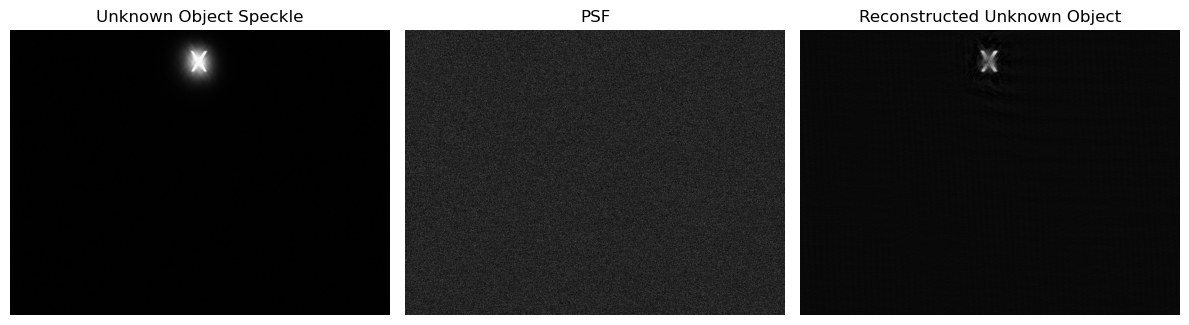

In [13]:
# 定义图像文件路径
ref_object_path = "参考物.png"
ref_speckle_path = "参考散斑.png"
unknown_speckle_path = "未遮挡的散斑.png"

try:
    # 加载并预处理图像
    # 首先加载一个图像以确定目标尺寸，确保所有图像尺寸一致
    # 这里假设所有图像原始尺寸就应该匹配，或用户会提供已匹配的图像
    # 如果不确定，可以先加载参考物，然后将其尺寸用于其他图像
    temp_img_for_size = cv2.imread(ref_object_path, cv2.IMREAD_GRAYSCALE)
    if temp_img_for_size is None:
        raise FileNotFoundError(f"Cannot load initial image to determine size: {ref_object_path}")
    target_size = (temp_img_for_size.shape[1], temp_img_for_size.shape[0]) # (width, height)

    O_ref = load_and_preprocess_image(ref_object_path, target_size)
    S_ref = load_and_preprocess_image(ref_speckle_path, target_size)
    S_unknown = load_and_preprocess_image(unknown_speckle_path, target_size)

    # 设置正则化参数 (可能需要根据实际情况调整)
    epsilon_value = 1e-4 # 这是一个经验值，具体数值可能需要调整

    # 重建未知物
    O_unknown_reconstructed, psf = reconstruct_object(O_ref, S_ref, S_unknown, epsilon=epsilon_value)

    # 显示原始图像和重建结果
    images_to_display = [S_unknown, psf, O_unknown_reconstructed]
    titles_for_display = [
        "Unknown Object Speckle",
        "PSF",
        "Reconstructed Unknown Object"
    ]
    display_images(images_to_display, titles_for_display)

    # 如果需要保存重建的图像
    # 首先将其转换到 0-255 的 uint8 范围
    reconstructed_normalized = (O_unknown_reconstructed - np.min(O_unknown_reconstructed)) / \
                            (np.max(O_unknown_reconstructed) - np.min(O_unknown_reconstructed) + 1e-9)
    reconstructed_uint8 = (reconstructed_normalized * 255).astype(np.uint8)
    # cv2.imwrite("重建结果_未知物图.png", reconstructed_uint8)
    # print("重建的未知物图像已保存为 重建结果_未知物图.png")

except FileNotFoundError as e:
    print(e)
except ValueError as e:
    print(e)
except Exception as e:
    print(f"发生意外错误: {e}")